# PASSO 4 - Modelagem de Ensemble
Nesta etapa, construímos e avaliamos modelos que combinam as predições de múltiplos algoritmos-base, visando obter uma generalização superior e maior estabilidade em cada um dos quatro eixos do MBTI.

Utilizamos os dois modelos de melhor desempenho nos experimentos anteriores como **Estimadores-Base**:
1. **Regressão Logística**
2. **XGBoost (Extreme Gradient Boosting)**

Para a junção dessas previsões, aplicamos duas abordagens de *Ensemble*:
* **Voto Majoritário (Voting Classifier)**
* **Blending**

As etapas abaixo dividem-se inicialmente em **Experimentos Padrão** (Base, SMOTE, Qwen), seguidos por células dedicadas exclusivamente aos experimentos com **GPT-2 + SMOTE**, concluindo com uma análise gráfica unificada.

In [6]:
import os
import pickle
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

from pipeline.utils.extras import divide_mbti
from pipeline.machine_learning_algorithms.logistic_regression import LogisticRegressionClassifier
from pipeline.machine_learning_algorithms.xgboost import XGBoostClassifier
from pipeline.machine_learning_algorithms.ensemble import MBTIEnsembleClassifier

with open('data/test_datasets/X_test_tfidf.pkl', 'rb') as f:
    X_test_tfidf = pickle.load(f)
with open('data/test_datasets/y_test.pkl', 'rb') as f:
    y_test_raw = pd.Series(pickle.load(f))
    
y_test_4cols = divide_mbti(y_test_raw)

with open('data/train_datasets/X_train_tfidf.pkl', 'rb') as f:
    X_train_tfidf = pickle.load(f)
with open('data/train_datasets/y_train.pkl', 'rb') as f:
    y_train = pd.Series(pickle.load(f))

X_train_orig_tfidf = X_train_tfidf[:6940]
y_train_orig = y_train[:6940]
y_train_4cols_orig = divide_mbti(y_train_orig)

dimensoes = ['I_E', 'N_S', 'T_F', 'J_P']
nomes_eixos = ['I/E\n(Introvert/Extravert)', 'N/S\n(Intuition/Sensing)', 'T/F\n(Thinking/Feeling)', 'J/P\n(Judging/Perceiving)']

## Função Auxiliar para Carregar o Esquadrão e Gerar Previsões

In [ ]:
def rodar_cenario_ensemble(sufixo_lr, sufixo_xgb, nome_cenario, resultados_f1):
    caminho_lr = 'models/logistic_regression'
    caminho_xgb = 'models/xgboost'
    
    clf_lr = LogisticRegressionClassifier(random_state=42)
    clf_xgb = XGBoostClassifier(random_state=42)
    
    for dim in dimensoes:
        arquivo_lr = f"{caminho_lr}/{dim}_{sufixo_lr}.pkl"
        arquivo_xgb = f"{caminho_xgb}/{dim}_{sufixo_xgb}.json"
        
        clf_lr.models[dim] = joblib.load(arquivo_lr)
        clf_xgb.models[dim].load_model(arquivo_xgb)
        
    base_models = {'LogisticRegression': clf_lr, 'XGBoost': clf_xgb}
    print(f"Cenário '{nome_cenario}' carregado com sucesso!")
    
    ensemble_voting = MBTIEnsembleClassifier(models_dict=base_models, ensemble_type='voting')
    ensemble_voting.fit(X_train_orig_tfidf, y_train_4cols_orig)
    pred_voting = ensemble_voting.predict(X_test_tfidf)
    
    ensemble_blending = MBTIEnsembleClassifier(models_dict=base_models, ensemble_type='blending')
    ensemble_blending.fit(X_train_orig_tfidf, y_train_4cols_orig)
    pred_blending = ensemble_blending.predict(X_test_tfidf)
    
    for i, col in enumerate(dimensoes):
        f1_voting = f1_score(y_test_4cols[col], pred_voting[col], average='weighted') * 100
        f1_blending = f1_score(y_test_4cols[col], pred_blending[col], average='weighted') * 100
        
        resultados_f1.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_voting, 'Cenário': nome_cenario, 'Ensemble': 'Voting'})
        resultados_f1.append({'Axis': nomes_eixos[i], 'F1 (%)': f1_blending, 'Cenário': nome_cenario, 'Ensemble': 'Blending'})
        
    print(f"Previsões geradas!\n")

## Execução dos Três Cenários

In [3]:
resultados_f1 = []

# 1: Base (No SMOTE)
rodar_cenario_ensemble(
    sufixo_lr="posts_tfidf_linear",
    sufixo_xgb="tfidf_qwen_original_posts",
    nome_cenario="Base (No SMOTE)",
    resultados_f1=resultados_f1
)

# 2: SMOTE
rodar_cenario_ensemble(
    sufixo_lr="posts_tfidf_linear_oversampled",
    sufixo_xgb="posts_tfidf_oversampled",
    nome_cenario="Apenas SMOTE",
    resultados_f1=resultados_f1
)

# 3: SMOTE + SLM Augmentation
rodar_cenario_ensemble(
    sufixo_lr="tfidf_linear",
    sufixo_xgb="tfidf_qwen",
    nome_cenario="SMOTE + SLM Augmentation",
    resultados_f1=resultados_f1
)

✅ Cenário 'Base (No SMOTE)' carregado com sucesso!
Starting voting ensemble training process...
 -> Fitting voting model for I_E...
 -> Fitting voting model for N_S...
 -> Fitting voting model for T_F...
 -> Fitting voting model for J_P...
All 4 ensemble dimensions fitted successfully! ✅
Starting blending ensemble training process...
 -> Fitting blending model for I_E...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/pytho

 -> Fitting blending model for N_S...
 -> Fitting blending model for T_F...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: inva

 -> Fitting blending model for J_P...
All 4 ensemble dimensions fitted successfully! ✅


...

All 4 ensemble dimensions fitted successfully! ✅
🎯 Previsões geradas!

✅ Cenário 'SMOTE + SLM Augmentation' carregado com sucesso!
Starting voting ensemble training process...
 -> Fitting voting model for I_E...
 -> Fitting voting model for N_S...
 -> Fitting voting model for T_F...
 -> Fitting voting model for J_P...
All 4 ensemble dimensions fitted successfully! ✅
Starting blending ensemble training process...
 -> Fitting blending model for I_E...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/pytho

 -> Fitting blending model for N_S...
 -> Fitting blending model for T_F...
 -> Fitting blending model for J_P...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: inva

All 4 ensemble dimensions fitted successfully! ✅
🎯 Previsões geradas!



## Gráfico Comparativo Final

/var/folders/5z/_8ywj3rn11x3yfxv7mczhpmh0000gn/T/ipykernel_28612/1627570728.py:28: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/5z/_8ywj3rn11x3yfxv7mczhpmh0000gn/T/ipykernel_28612/1627570728.py:28: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


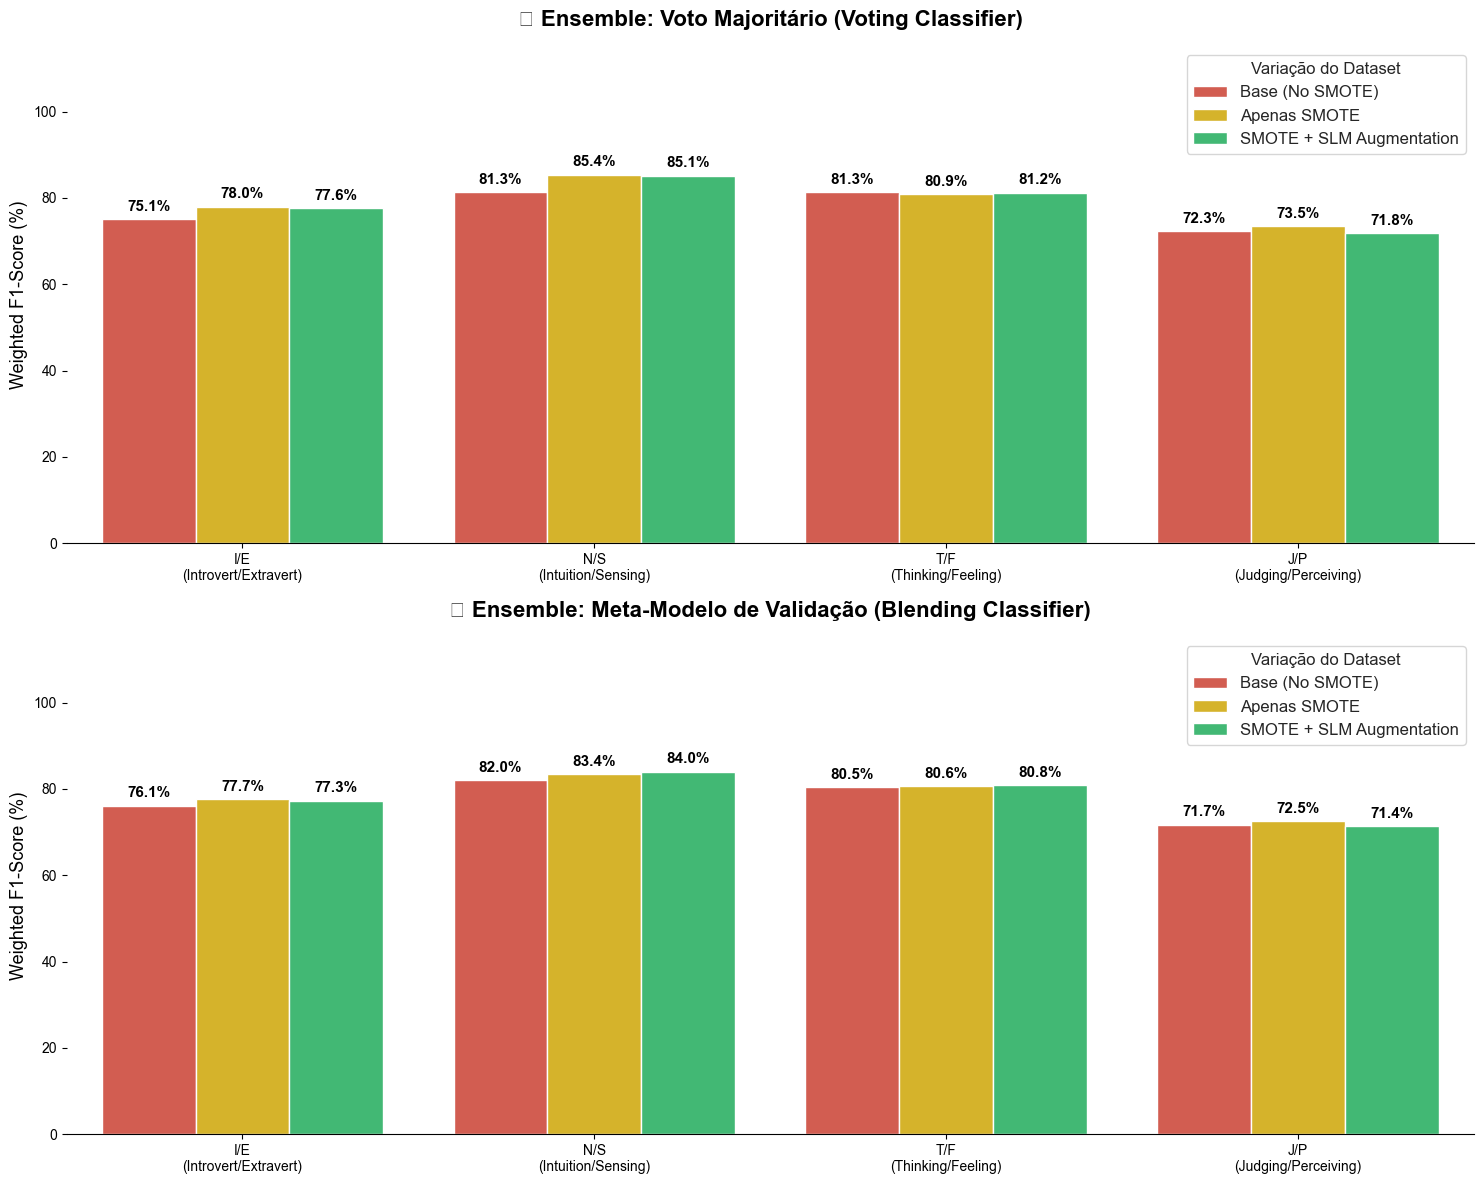

In [ ]:
df_plot = pd.DataFrame(resultados_f1)

fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharey=True)
sns.set_theme(style="whitegrid")
paleta = ['#e74c3c', '#f1c40f', '#2ecc71']

sns.barplot(data=df_plot[df_plot['Ensemble'] == 'Voting'], x='Axis', y='F1 (%)', hue='Cenário', palette=paleta, ax=axes[0])
axes[0].set_title("Ensemble: Voto Majoritário (Voting Classifier)", fontsize=16, fontweight='bold', pad=15)
axes[0].set_ylim(0, 115)
axes[0].set_ylabel("Weighted F1-Score (%)", fontsize=13)
axes[0].set_xlabel("")

sns.barplot(data=df_plot[df_plot['Ensemble'] == 'Blending'], x='Axis', y='F1 (%)', hue='Cenário', palette=paleta, ax=axes[1])
axes[1].set_title("Ensemble: Meta-Modelo de Validação (Blending Classifier)", fontsize=16, fontweight='bold', pad=15)
axes[1].set_ylabel("Weighted F1-Score (%)", fontsize=13)
axes[1].set_xlabel("")

for ax in axes:
    for p in ax.patches:
        altura = p.get_height()
        if altura > 0:
            ax.annotate(f"{altura:.1f}%", (p.get_x() + p.get_width() / 2., altura), 
                        ha='center', va='baseline', fontsize=11, fontweight='bold', color='black', 
                        xytext=(0, 6), textcoords='offset points')
    ax.legend(title='Variação do Dataset', fontsize='12', loc='upper right')

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

In [1]:
## FAZENDO MAIS UM TESTE ISOLADO COM O GPT2

In [22]:
import pickle
import pandas as pd

from pipeline.utils.extras import divide_mbti


with open('data/train_datasets/X_train_tfidf_gpt2.pkl', 'rb') as f:
    X_train_tfidf_gpt2 = pickle.load(f)

with open('data/test_datasets/X_test_tfidf_gpt2.pkl', 'rb') as f:
    X_test_tfidf_gpt2 = pickle.load(f)


# labels
with open('data/train_datasets/y_train_gpt2.pkl', 'rb') as f:
    y_train = pd.Series(pickle.load(f))

with open('data/test_datasets/y_test_gpt2.pkl', 'rb') as f:
    y_test = pd.Series(pickle.load(f))


y_train_gpt2 = y_train

y_train_gpt2_4cols = divide_mbti(y_train_gpt2)
y_test_4cols = divide_mbti(y_test)


print("Train GPT2:", y_train_gpt2.shape)
print("Test GPT2:", y_test_4cols.shape)

Train GPT2: (9322,)
Test GPT2: (1735, 4)


In [23]:
# Criar objetos vazios
clf_lr_gpt2 = LogisticRegressionClassifier(
    random_state=42
)

clf_xgb_gpt2 = XGBoostClassifier(
    random_state=42
)


# Carregar modelos salvos
clf_lr_gpt2.load_models(
    label="tfidf_gpt2",
    models_dir="models/logistic_regression"
)


clf_xgb_gpt2.load_models(
    label="tfidf_aug",
    models_dir="models/xgboost"
)


base_models_gpt2 = {
    "LogisticRegression": clf_lr_gpt2,
    "XGBoost": clf_xgb_gpt2
}


print("Modelos GPT2 carregados!")

Loading models/logistic_regression/I_E_tfidf_gpt2.pkl
Loading models/logistic_regression/N_S_tfidf_gpt2.pkl
Loading models/logistic_regression/T_F_tfidf_gpt2.pkl
Loading models/logistic_regression/J_P_tfidf_gpt2.pkl
All models loaded successfully! ✅
Loading models/xgboost/I_E_tfidf_aug.json
Loading models/xgboost/N_S_tfidf_aug.json
Loading models/xgboost/T_F_tfidf_aug.json
Loading models/xgboost/J_P_tfidf_aug.json
All models loaded successfully! ✅
Modelos GPT2 carregados!


In [24]:
from sklearn.metrics import f1_score


resultados_f1_gpt2 = []


# ======================
# Voting
# ======================

ensemble_voting_gpt2 = MBTIEnsembleClassifier(
    models_dict=base_models_gpt2,
    ensemble_type="voting"
)


ensemble_voting_gpt2.fit(
    X_train_tfidf_gpt2,
    y_train_gpt2_4cols
)


pred_voting_gpt2 = ensemble_voting_gpt2.predict(
    X_test_tfidf_gpt2
)



# ======================
# Blending
# ======================

ensemble_blending_gpt2 = MBTIEnsembleClassifier(
    models_dict=base_models_gpt2,
    ensemble_type="blending"
)


ensemble_blending_gpt2.fit(
    X_train_tfidf_gpt2,
    y_train_gpt2_4cols
)


pred_blending_gpt2 = ensemble_blending_gpt2.predict(
    X_test_tfidf_gpt2
)



# ======================
# Métricas
# ======================

nomes_eixos = [
    'I/E\n(Introvert/Extravert)',
    'N/S\n(Intuition/Sensing)',
    'T/F\n(Thinking/Feeling)',
    'J/P\n(Judging/Perceiving)'
]


dimensoes = ['I_E', 'N_S', 'T_F', 'J_P']


for i, dim in enumerate(dimensoes):

    f1_voting = (
        f1_score(
            y_test_4cols[dim],
            pred_voting_gpt2[dim],
            average="weighted"
        ) * 100
    )


    f1_blending = (
        f1_score(
            y_test_4cols[dim],
            pred_blending_gpt2[dim],
            average="weighted"
        ) * 100
    )


    resultados_f1_gpt2.append({
        "Axis": nomes_eixos[i],
        "F1 (%)": f1_voting,
        "Cenário": "GPT2",
        "Ensemble": "Voting"
    })


    resultados_f1_gpt2.append({
        "Axis": nomes_eixos[i],
        "F1 (%)": f1_blending,
        "Cenário": "GPT2",
        "Ensemble": "Blending"
    })


df_gpt2 = pd.DataFrame(resultados_f1_gpt2)

df_gpt2

Starting voting ensemble training process...
 -> Fitting voting model for I_E...
 -> Fitting voting model for N_S...
 -> Fitting voting model for T_F...
 -> Fitting voting model for J_P...
All 4 ensemble dimensions fitted successfully! ✅
Starting blending ensemble training process...
 -> Fitting blending model for I_E...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/pytho

 -> Fitting blending model for N_S...
 -> Fitting blending model for T_F...


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath

 -> Fitting blending model for J_P...
All 4 ensemble dimensions fitted successfully! ✅


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath

,Axis,F1 (%),Cenário,Ensemble
0,I/E\n(Introvert/Extravert),77.017799,GPT2,Voting
1,I/E\n(Introvert/Extravert),76.924009,GPT2,Blending
2,N/S\n(Intuition/Sensing),85.601208,GPT2,Voting
3,N/S\n(Intuition/Sensing),84.101533,GPT2,Blending
4,T/F\n(Thinking/Feeling),80.433233,GPT2,Voting
5,T/F\n(Thinking/Feeling),80.762344,GPT2,Blending
6,J/P\n(Judging/Perceiving),71.991111,GPT2,Voting
7,J/P\n(Judging/Perceiving),71.176425,GPT2,Blending


In [25]:
import pandas as pd

resultados_previos = [

    {'Axis': 'I/E\n(Introvert/Extravert)', 'F1 (%)': 75.1, 'Cenário': 'Base (No SMOTE)', 'Ensemble': 'Voting'},
    {'Axis': 'N/S\n(Intuition/Sensing)', 'F1 (%)': 81.3, 'Cenário': 'Base (No SMOTE)', 'Ensemble': 'Voting'},
    {'Axis': 'T/F\n(Thinking/Feeling)', 'F1 (%)': 81.3, 'Cenário': 'Base (No SMOTE)', 'Ensemble': 'Voting'},
    {'Axis': 'J/P\n(Judging/Perceiving)', 'F1 (%)': 72.3, 'Cenário': 'Base (No SMOTE)', 'Ensemble': 'Voting'},

    {'Axis': 'I/E\n(Introvert/Extravert)', 'F1 (%)': 78.0, 'Cenário': 'Apenas SMOTE', 'Ensemble': 'Voting'},
    {'Axis': 'N/S\n(Intuition/Sensing)', 'F1 (%)': 85.4, 'Cenário': 'Apenas SMOTE', 'Ensemble': 'Voting'},
    {'Axis': 'T/F\n(Thinking/Feeling)', 'F1 (%)': 80.9, 'Cenário': 'Apenas SMOTE', 'Ensemble': 'Voting'},
    {'Axis': 'J/P\n(Judging/Perceiving)', 'F1 (%)': 73.5, 'Cenário': 'Apenas SMOTE', 'Ensemble': 'Voting'},

    {'Axis': 'I/E\n(Introvert/Extravert)', 'F1 (%)': 77.6, 'Cenário': 'SMOTE + SLM Augmentation', 'Ensemble': 'Voting'},
    {'Axis': 'N/S\n(Intuition/Sensing)', 'F1 (%)': 85.1, 'Cenário': 'SMOTE + SLM Augmentation', 'Ensemble': 'Voting'},
    {'Axis': 'T/F\n(Thinking/Feeling)', 'F1 (%)': 81.2, 'Cenário': 'SMOTE + SLM Augmentation', 'Ensemble': 'Voting'},
    {'Axis': 'J/P\n(Judging/Perceiving)', 'F1 (%)': 71.8, 'Cenário': 'SMOTE + SLM Augmentation', 'Ensemble': 'Voting'},

    {'Axis': 'I/E\n(Introvert/Extravert)', 'F1 (%)': 76.1, 'Cenário': 'Base (No SMOTE)', 'Ensemble': 'Blending'},
    {'Axis': 'N/S\n(Intuition/Sensing)', 'F1 (%)': 82.0, 'Cenário': 'Base (No SMOTE)', 'Ensemble': 'Blending'},
    {'Axis': 'T/F\n(Thinking/Feeling)', 'F1 (%)': 80.5, 'Cenário': 'Base (No SMOTE)', 'Ensemble': 'Blending'},
    {'Axis': 'J/P\n(Judging/Perceiving)', 'F1 (%)': 71.7, 'Cenário': 'Base (No SMOTE)', 'Ensemble': 'Blending'},

    {'Axis': 'I/E\n(Introvert/Extravert)', 'F1 (%)': 77.7, 'Cenário': 'Apenas SMOTE', 'Ensemble': 'Blending'},
    {'Axis': 'N/S\n(Intuition/Sensing)', 'F1 (%)': 83.4, 'Cenário': 'Apenas SMOTE', 'Ensemble': 'Blending'},
    {'Axis': 'T/F\n(Thinking/Feeling)', 'F1 (%)': 80.6, 'Cenário': 'Apenas SMOTE', 'Ensemble': 'Blending'},
    {'Axis': 'J/P\n(Judging/Perceiving)', 'F1 (%)': 72.5, 'Cenário': 'Apenas SMOTE', 'Ensemble': 'Blending'},

    {'Axis': 'I/E\n(Introvert/Extravert)', 'F1 (%)': 77.3, 'Cenário': 'SMOTE + SLM Augmentation', 'Ensemble': 'Blending'},
    {'Axis': 'N/S\n(Intuition/Sensing)', 'F1 (%)': 84.0, 'Cenário': 'SMOTE + SLM Augmentation', 'Ensemble': 'Blending'},
    {'Axis': 'T/F\n(Thinking/Feeling)', 'F1 (%)': 80.8, 'Cenário': 'SMOTE + SLM Augmentation', 'Ensemble': 'Blending'},
    {'Axis': 'J/P\n(Judging/Perceiving)', 'F1 (%)': 71.4, 'Cenário': 'SMOTE + SLM Augmentation', 'Ensemble': 'Blending'},

]

df_manual = pd.DataFrame(resultados_previos)

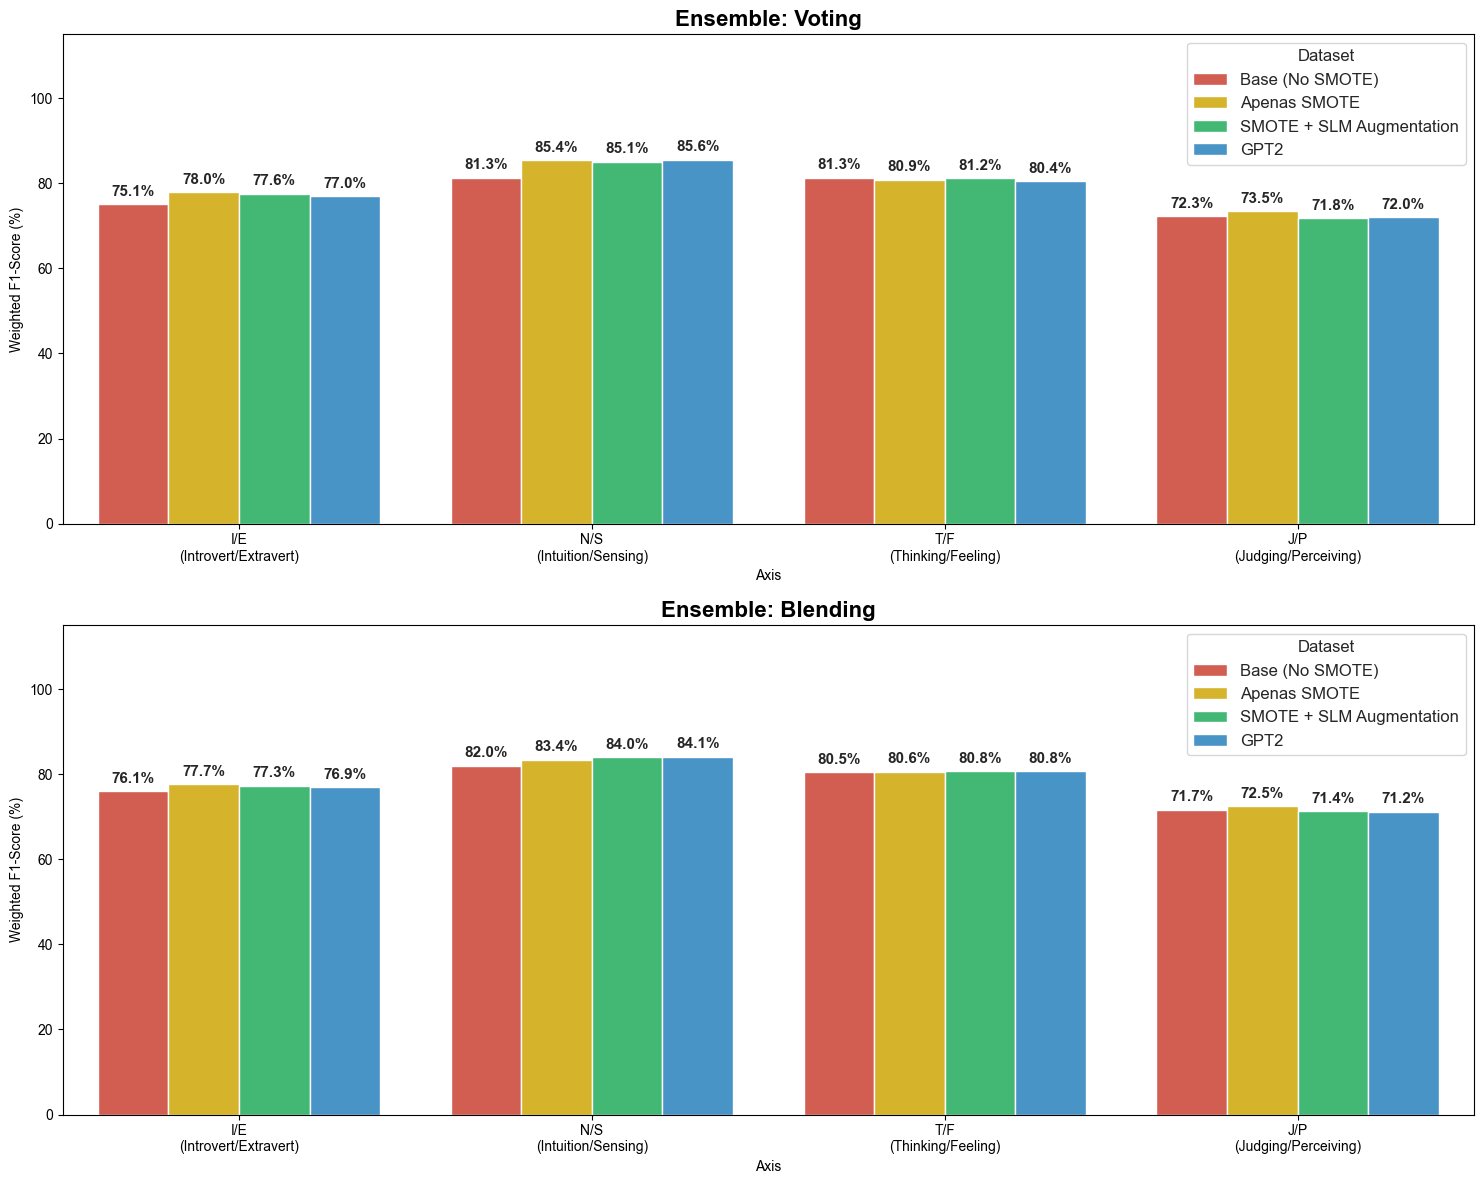

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt


df_final = pd.concat(
    [
        df_manual,
        df_gpt2
    ],
    ignore_index=True
)


fig, axes = plt.subplots(
    2, 
    1,
    figsize=(15, 12),
    sharey=True
)


sns.set_theme(style="whitegrid")

paleta = [
    '#e74c3c',
    '#f1c40f',
    '#2ecc71',
    '#3498db'
]


for ensemble_type, ax in zip(
    ['Voting', 'Blending'],
    axes
):

    sns.barplot(
        data=df_final[df_final['Ensemble'] == ensemble_type],
        x='Axis',
        y='F1 (%)',
        hue='Cenário',
        palette=paleta,
        ax=ax
    )


    ax.set_title(
        f"Ensemble: {ensemble_type}",
        fontsize=16,
        fontweight='bold'
    )

    ax.set_ylim(0, 115)
    ax.set_ylabel("Weighted F1-Score (%)")


    for p in ax.patches:
        altura = p.get_height()

        if altura > 0:
            ax.annotate(
                f"{altura:.1f}%",
                (
                    p.get_x() + p.get_width()/2.,
                    altura
                ),
                ha='center',
                va='baseline',
                fontsize=11,
                fontweight='bold',
                xytext=(0,6),
                textcoords='offset points'
            )


    ax.legend(
        title='Dataset',
        fontsize='12'
    )


plt.tight_layout()
plt.show()